# Links to Github and Streamlit

Github: https://github.com/mohamadalkawadri/mohamadalkawadri-IND320-project branch name is assignment-3

Streamlit: https://mohamadalkawadri-ind320-project-assign.streamlit.app/

# AI usage



# Log describing the compulsory work



In [1]:
import pandas as pd

# Representative cities for Norway's five electricity price areas
data = [
    {"price_area": "NO1", "city": "Oslo",         "latitude": 59.9139, "longitude": 10.7522},
    {"price_area": "NO2", "city": "Kristiansand", "latitude": 58.1467, "longitude": 7.9956},
    {"price_area": "NO3", "city": "Trondheim",    "latitude": 63.4305, "longitude": 10.3951},
    {"price_area": "NO4", "city": "Tromsø",       "latitude": 69.6492, "longitude": 18.9553},
    {"price_area": "NO5", "city": "Bergen",       "latitude": 60.3913, "longitude": 5.3221},
]

df = pd.DataFrame(data, columns=["price_area", "city", "latitude", "longitude"])
df

,price_area,city,latitude,longitude
0,NO1,Oslo,59.9139,10.7522
1,NO2,Kristiansand,58.1467,7.9956
2,NO3,Trondheim,63.4305,10.3951
3,NO4,Tromsø,69.6492,18.9553
4,NO5,Bergen,60.3913,5.3221


In [ ]:
!pip install openmeteo-requests requests-cache retry-requests 

In [7]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

def download_era5_hourly(latitude: float, longitude: float, year: int) -> pd.DataFrame:

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": f"{year}-01-01",
        "end_date": f"{year}-12-31",
        "hourly": [
            "temperature_2m",
            "precipitation",
            "wind_speed_10m",
            "wind_gusts_10m",
            "wind_direction_10m"
        ],
    }

    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]

    # Process hourly data
    hourly = response.Hourly()
    data = {
        "time": pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left"
        ),
        "temperature_2m": hourly.Variables(0).ValuesAsNumpy(),
        "precipitation": hourly.Variables(1).ValuesAsNumpy(),
        "wind_speed_10m": hourly.Variables(2).ValuesAsNumpy(),
        "wind_gusts_10m": hourly.Variables(3).ValuesAsNumpy(),
        "wind_direction_10m": hourly.Variables(4).ValuesAsNumpy(),
    }

    df = pd.DataFrame(data)
    return df


bergen_data_2019 = download_era5_hourly(60.3913, 5.3221, 2019)
bergen_data_2019

,time,temperature_2m,precipitation,wind_speed_10m,wind_gusts_10m,wind_direction_10m
0,2019-01-01 00:00:00+00:00,5.7915,0.2,41.036842,107.279991,277.561340
1,2019-01-01 01:00:00+00:00,6.0915,0.7,42.033756,111.959999,286.417297
2,2019-01-01 02:00:00+00:00,6.3415,0.5,40.913490,105.839996,298.368958
3,2019-01-01 03:00:00+00:00,5.8415,1.1,41.238468,110.159996,315.000092
4,2019-01-01 04:00:00+00:00,5.7415,0.7,44.140755,107.279991,322.288879
...,...,...,...,...,...,...
8755,2019-12-31 19:00:00+00:00,4.9915,0.7,11.525623,29.160000,218.659836
8756,2019-12-31 20:00:00+00:00,5.8915,0.7,12.984975,35.279999,226.123215
8757,2019-12-31 21:00:00+00:00,6.3915,0.3,14.618837,37.439999,217.998779
8758,2019-12-31 22:00:00+00:00,6.1415,0.1,13.684735,36.719997,206.564987


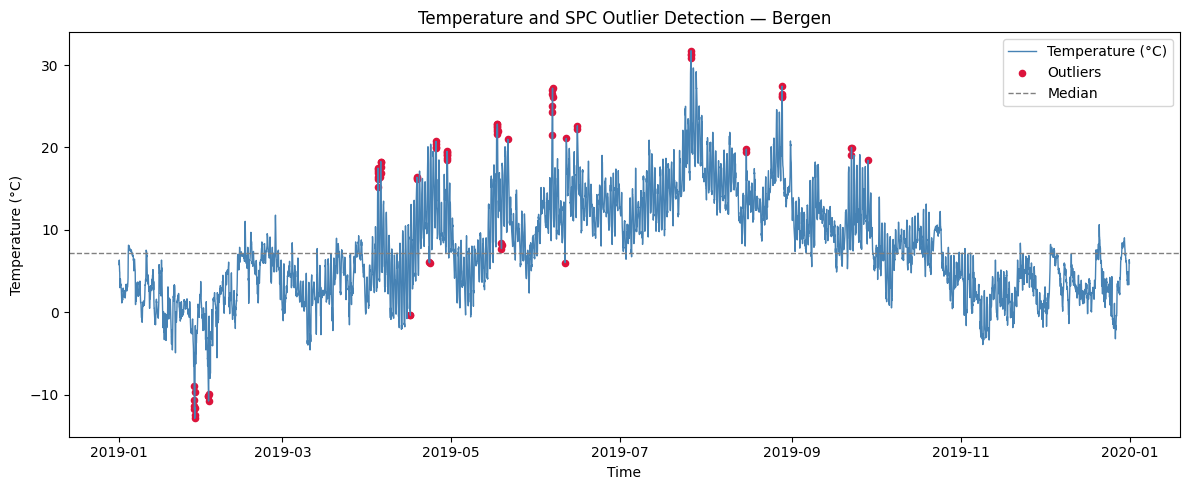

({'city': 'Bergen',
  'n_observations': 8760,
  'n_outliers': np.int64(79),
  'outlier_fraction (%)': np.float64(0.9),
  'robust_std': np.float32(2.3268526),
  'upper_limit': np.float32(6.9403934),
  'lower_limit': np.float32(-7.0207214)},
                           time  temperature_2m  precipitation  wind_speed_10m  \
 651  2019-01-28 03:00:00+00:00       -8.958500            0.0        6.480000   
 652  2019-01-28 04:00:00+00:00      -10.608500            0.0        5.241679   
 653  2019-01-28 05:00:00+00:00      -11.308499            0.0        5.447788   
 654  2019-01-28 06:00:00+00:00      -11.758500            0.0        5.400000   
 655  2019-01-28 07:00:00+00:00      -11.558499            0.0        5.411986   
 ...                        ...             ...            ...             ...   
 5749 2019-08-28 13:00:00+00:00       26.291500            0.0        9.422101   
 6348 2019-09-22 12:00:00+00:00       19.141499            0.0        1.800000   
 6349 2019-09-22 13:00

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct

def plot_temperature_with_spc(
    df: pd.DataFrame,
    cutoff: int = 100,          # DCT high-pass cutoff frequency
    n_sigma: float = 3.0,       # number of robust stds (MADs) for control limits
    city: str = "Unknown"
):
    """
    Plot temperature vs time, perform DCT high-pass filtering to compute
    seasonally adjusted temperature variations (SATV), and visualize SPC boundaries.
    """
    
    # --- 1. Prepare temperature data ---
    temp = df["temperature_2m"].values
    time = pd.to_datetime(df["time"])
    
    # --- 2. Apply Discrete Cosine Transform (DCT) for high-pass filtering ---
    dct_coeffs = dct(temp, norm='ortho')
    
    # Remove low-frequency (seasonal) components: keep only high frequencies
    dct_high = np.copy(dct_coeffs)
    dct_high[:cutoff] = 0  # zero out low frequencies
    
    satv = idct(dct_high, norm='ortho')  # seasonally adjusted temp variations (HP-filtered)
    
    # --- 3. Compute robust SPC limits using MAD ---
    median_satv = np.median(satv)
    mad = np.median(np.abs(satv - median_satv))
    robust_std = 1.4826 * mad  # convert MAD to std estimate
    
    upper_limit = median_satv + n_sigma * robust_std
    lower_limit = median_satv - n_sigma * robust_std
    
    # --- 4. Identify outliers ---
    outlier_mask = (satv > upper_limit) | (satv < lower_limit)
    outliers = df[outlier_mask].copy()
    outliers["SATV"] = satv[outlier_mask]
    
    # --- 5. Plot ---
    plt.figure(figsize=(12, 5))
    plt.plot(time, temp, label="Temperature (°C)", color="steelblue", linewidth=1)
    plt.scatter(time[outlier_mask], temp[outlier_mask], color="crimson", label="Outliers", s=20)
    
    plt.axhline(np.median(temp), color="gray", linestyle="--", linewidth=1, label="Median")
    plt.title(f"Temperature and SPC Outlier Detection — {city}")
    plt.xlabel("Time")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # --- 6. Summary ---
    summary = {
        "city": city,
        "n_observations": len(df),
        "n_outliers": outlier_mask.sum(),
        "outlier_fraction (%)": round(100 * outlier_mask.mean(), 2),
        "robust_std": robust_std,
        "upper_limit": upper_limit,
        "lower_limit": lower_limit
    }
    
    return summary, outliers

plot_temperature_with_spc(bergen_data_2019, city="Bergen")

/Users/mohamad/anaconda3/envs/D2D_env/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


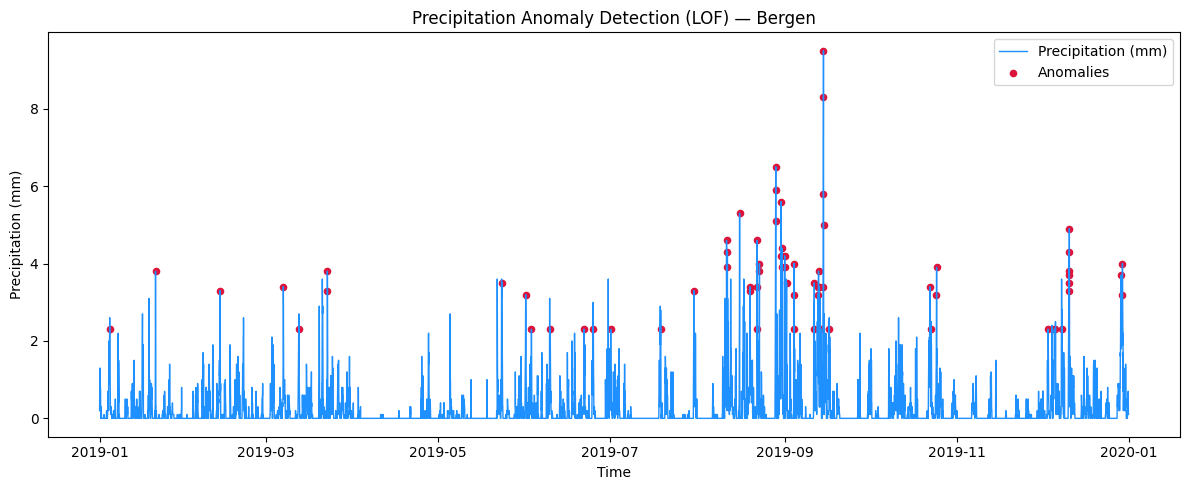

({'city': 'Bergen',
  'n_observations': 8760,
  'n_outliers': np.int64(72),
  'outlier_fraction (%)': np.float64(0.82),
  'mean_precip (mm)': np.float32(0.24644975),
  'max_precip (mm)': np.float32(9.5),
  'median_outlier_score': np.float32(1.3525877)},
                           time  temperature_2m  precipitation  wind_speed_10m  \
 87   2019-01-04 15:00:00+00:00          8.0415            2.3       18.000000   
 476  2019-01-20 20:00:00+00:00          1.3415            3.8       20.991426   
 1025 2019-02-12 17:00:00+00:00          4.2915            3.3       19.011953   
 1564 2019-03-07 04:00:00+00:00          1.5415            3.4        9.904906   
 1695 2019-03-12 15:00:00+00:00          2.3415            2.3       20.858265   
 ...                        ...             ...            ...             ...   
 8255 2019-12-10 23:00:00+00:00          7.0915            4.9       24.675106   
 8256 2019-12-11 00:00:00+00:00          5.4915            3.5       17.873556   
 8693 20

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

def plot_precipitation_with_lof(
    df: pd.DataFrame,
    contamination: float = 0.01,  # proportion of outliers (default = 1%)
    city: str = "Unknown"
):
    """
    Plot precipitation vs time and detect anomalies using Local Outlier Factor (LOF).
    """
    # --- 1. Extract relevant series ---
    precip = df["precipitation"].values.reshape(-1, 1)
    time = pd.to_datetime(df["time"])

    # --- 2. Fit LOF model ---
    lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination)
    labels = lof.fit_predict(precip)  # -1 = outlier, 1 = inlier
    lof_scores = -lof.negative_outlier_factor_  # higher = more anomalous

    # --- 3. Identify outliers ---
    outlier_mask = labels == -1
    outliers = df[outlier_mask].copy()
    outliers["lof_score"] = lof_scores[outlier_mask]

    # --- 4. Plot results ---
    plt.figure(figsize=(12, 5))
    plt.plot(time, precip, label="Precipitation (mm)", color="dodgerblue", linewidth=1)
    plt.scatter(time[outlier_mask], precip[outlier_mask], color="crimson", label="Anomalies", s=20)
    
    plt.title(f"Precipitation Anomaly Detection (LOF) — {city}")
    plt.xlabel("Time")
    plt.ylabel("Precipitation (mm)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- 5. Summary statistics ---
    summary = {
        "city": city,
        "n_observations": len(df),
        "n_outliers": outlier_mask.sum(),
        "outlier_fraction (%)": round(100 * outlier_mask.mean(), 2),
        "mean_precip (mm)": np.mean(precip),
        "max_precip (mm)": np.max(precip),
        "median_outlier_score": np.median(outliers["lof_score"]) if not outliers.empty else None
    }

    return summary, outliers

plot_precipitation_with_lof(bergen_data_2019, city="Bergen")

/var/folders/v8/80_fy0397t5c_tv0p8pd45q80000gn/T/ipykernel_41276/2629048178.py:28: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  t = pd.to_datetime(data["startTime"])


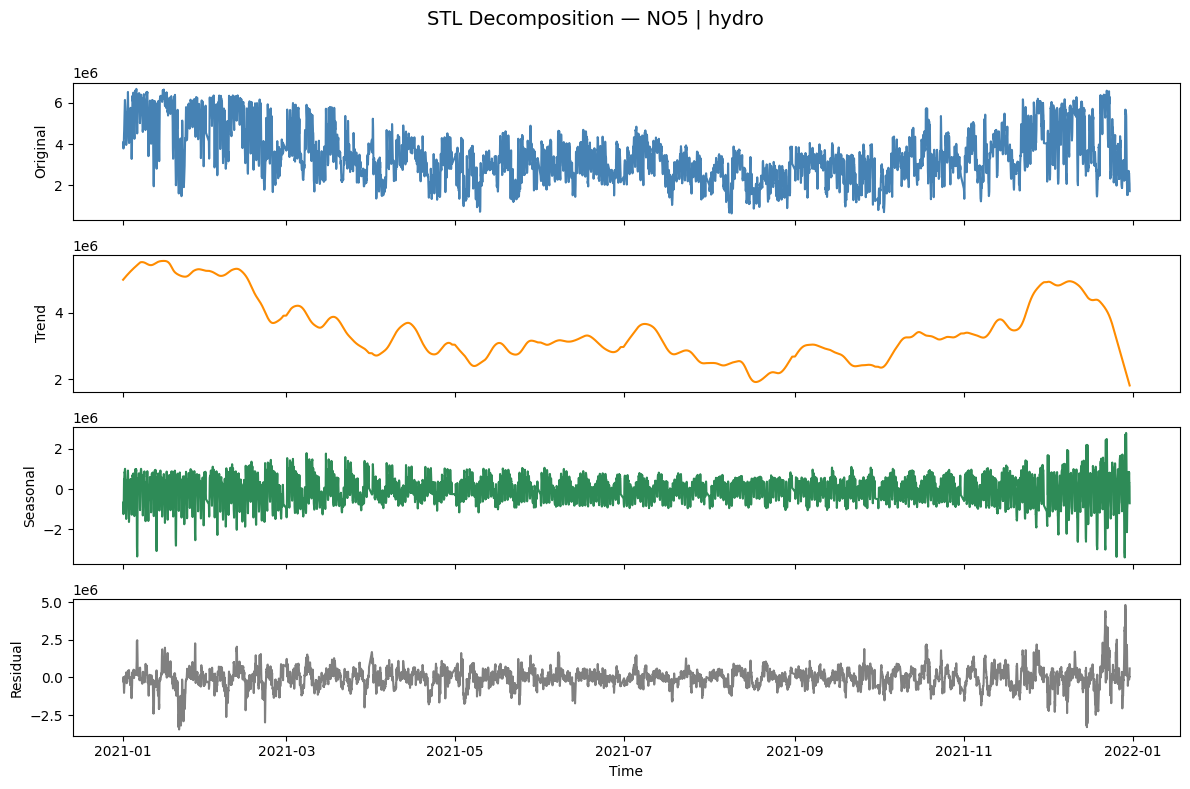

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

def plot_stl_decomposition(
    df: pd.DataFrame,
    area: str = "NO5",
    group: str = "Hydro",
    period: int = 24*7,            # default: one week of hourly seasonality
    seasonal_smoother: int = 13,   # smoother window for seasonal component
    trend_smoother: int = 301,     # smoother window for trend component
    robust: bool = True            # robust to outliers
):
    """
    Perform STL decomposition (Seasonal-Trend decomposition using LOESS)
    on electricity production data filtered by area and production group.
    """

    # --- 1. Filter data for chosen area & group ---
    mask = (df["priceArea"] == area) & (df["productionGroup"] == group)
    data = df.loc[mask].copy()

    if data.empty:
        raise ValueError(f"No data found for area={area} and group={group}")

    data = data.sort_values("startTime")
    y = data["quantityKwh"].astype(float).values
    t = pd.to_datetime(data["startTime"])

    # --- 2. Apply STL decomposition ---
    stl = STL(
        y,
        period=period,
        seasonal=seasonal_smoother,
        trend=trend_smoother,
        robust=robust
    ).fit()

    # --- 3. Plot decomposition ---
    fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(f"STL Decomposition — {area} | {group}", fontsize=14)

    axes[0].plot(t, y, color="steelblue")
    axes[0].set_ylabel("Original")

    axes[1].plot(t, stl.trend, color="darkorange")
    axes[1].set_ylabel("Trend")

    axes[2].plot(t, stl.seasonal, color="seagreen")
    axes[2].set_ylabel("Seasonal")

    axes[3].plot(t, stl.resid, color="gray")
    axes[3].set_ylabel("Residual")
    axes[3].set_xlabel("Time")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    return stl

elhub = pd.read_csv('norway_energy_2021.csv')
plot_stl_decomposition(elhub, area="NO5", group="hydro")

/var/folders/v8/80_fy0397t5c_tv0p8pd45q80000gn/T/ipykernel_41276/986860286.py:38: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  t = pd.to_datetime(data["startTime"])


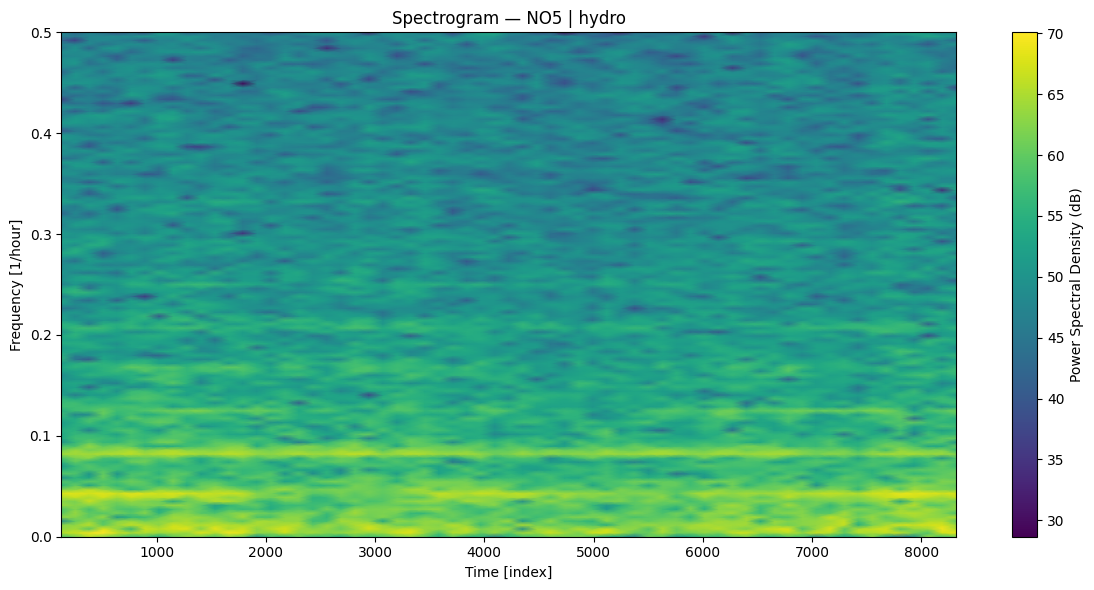

(array([0.        , 0.00390625, 0.0078125 , 0.01171875, 0.015625  ,
        0.01953125, 0.0234375 , 0.02734375, 0.03125   , 0.03515625,
        0.0390625 , 0.04296875, 0.046875  , 0.05078125, 0.0546875 ,
        0.05859375, 0.0625    , 0.06640625, 0.0703125 , 0.07421875,
        0.078125  , 0.08203125, 0.0859375 , 0.08984375, 0.09375   ,
        0.09765625, 0.1015625 , 0.10546875, 0.109375  , 0.11328125,
        0.1171875 , 0.12109375, 0.125     , 0.12890625, 0.1328125 ,
        0.13671875, 0.140625  , 0.14453125, 0.1484375 , 0.15234375,
        0.15625   , 0.16015625, 0.1640625 , 0.16796875, 0.171875  ,
        0.17578125, 0.1796875 , 0.18359375, 0.1875    , 0.19140625,
        0.1953125 , 0.19921875, 0.203125  , 0.20703125, 0.2109375 ,
        0.21484375, 0.21875   , 0.22265625, 0.2265625 , 0.23046875,
        0.234375  , 0.23828125, 0.2421875 , 0.24609375, 0.25      ,
        0.25390625, 0.2578125 , 0.26171875, 0.265625  , 0.26953125,
        0.2734375 , 0.27734375, 0.28125   , 0.28

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

def plot_production_spectrogram(
    df: pd.DataFrame,
    area: str = "NO5",
    group: str = "Hydro",
    window_length: int = 256,   # number of samples per FFT window
    overlap: int = 128          # overlap between windows
):
    """
    Compute and plot a spectrogram for Elhub production data.
    
    Parameters
    ----------
    df : pd.DataFrame
        Elhub production data with columns: priceArea, productionGroup, startTime, quantityKwh
    area : str
        Electricity price area (e.g., "NO1"..."NO5")
    group : str
        Production group (e.g., "Hydro", "Wind", "Thermal")
    window_length : int
        FFT window length (number of samples per segment)
    overlap : int
        Number of overlapping samples between windows
    """
    
    # --- 1. Filter relevant subset ---
    mask = (df["priceArea"] == area) & (df["productionGroup"] == group)
    data = df.loc[mask].copy()
    if data.empty:
        raise ValueError(f"No data found for area={area} and group={group}")
        
    data = data.sort_values("startTime")
    y = data["quantityKwh"].astype(float).values
    t = pd.to_datetime(data["startTime"])

    # --- 2. Compute spectrogram ---
    fs = 1.0  # sampling frequency (1/hour if hourly data)
    f, t_spec, Sxx = spectrogram(
        y,
        fs=fs,
        nperseg=window_length,
        noverlap=overlap,
        scaling="density",
        detrend="linear",
        mode="magnitude"
    )

    # --- 3. Plot ---
    plt.figure(figsize=(12, 6))
    plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-10), shading="gouraud", cmap="viridis")
    plt.colorbar(label="Power Spectral Density (dB)")
    plt.title(f"Spectrogram — {area} | {group}")
    plt.ylabel("Frequency [1/hour]")
    plt.xlabel("Time [index]")
    plt.tight_layout()
    plt.show()
    
    return f, t_spec, Sxx



plot_production_spectrogram(elhub, area="NO5", group="hydro")